### EDA

In [1]:
import pandas as pd
from sklearn.model_selection import GridSearchCV,cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,mean_absolute_error,f1_score
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [2]:
import os
get = os.getcwd()
if get == '/content':
    %cd /content/Titanic
else:
    train_data = pd.read_csv('data/train.csv',index_col='PassengerId')
    test_data = pd.read_csv('data/test.csv')



In [17]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
train_data.describe().round() #вывожу общую информацию

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.0,714.0,891.0,891.0,891.0
mean,0.0,2.0,30.0,1.0,0.0,32.0
std,0.0,1.0,15.0,1.0,1.0,50.0
min,0.0,1.0,0.0,0.0,0.0,0.0
25%,0.0,2.0,20.0,0.0,0.0,8.0
50%,0.0,3.0,28.0,0.0,0.0,14.0
75%,1.0,3.0,38.0,1.0,0.0,31.0
max,1.0,3.0,80.0,8.0,6.0,512.0


In [18]:
train_data.isna().sum() #смотрю пропуски

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [14]:
print(train_data.shape)
test_data.shape

(891, 11)


(418, 11)

In [28]:
train_data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

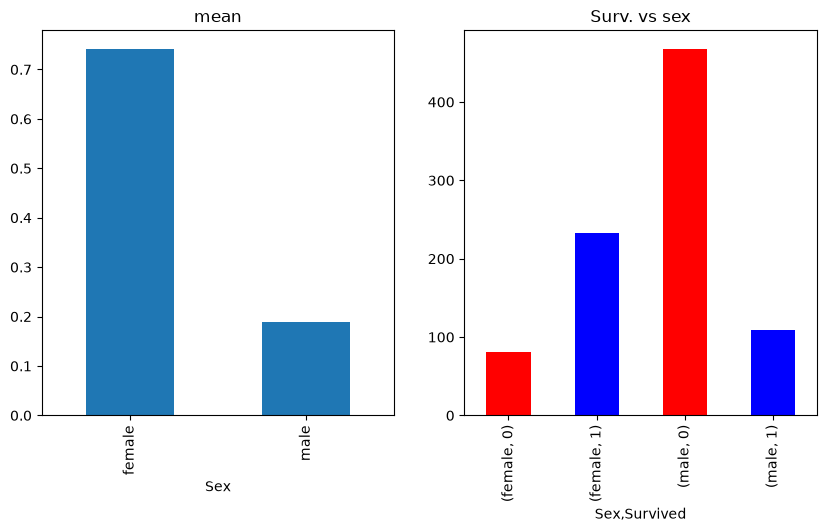

In [62]:
f,ax = plt.subplots(1,2,figsize=(10,5))
train_data.groupby('Sex')['Survived'].mean().plot.bar(ax=ax[0])
ax[0].set_title('mean')
train_data.groupby(['Sex','Survived'])['Survived'].count().plot.bar(ax=ax[1],color=['r','b','r','b'])
ax[1].set_title('Surv. vs sex')
plt.show()

По графику видно, что мужчины умирали сильно чаще, чем женщины. Поэтому для целевой переменной это является хорошим признаком.

<Axes: >

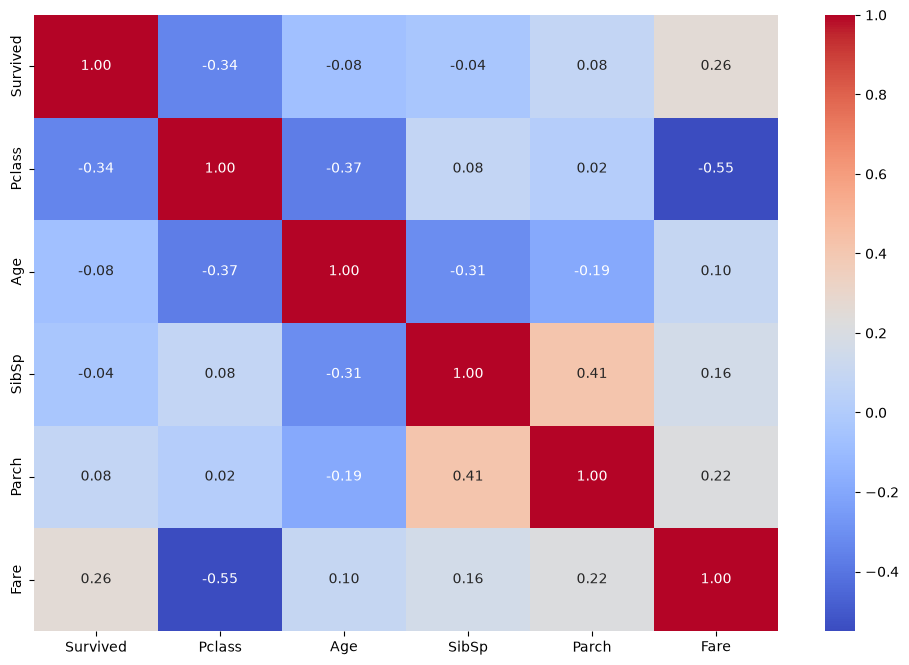

In [64]:
plt.figure(figsize=(12,8))
corr = train_data.corr(numeric_only=True)

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')

Видим небольшую зависимость между таргетом и Fare, а также обратную зависимость с Pclass. Можем сделать вывод: Чем выше класс, тем меньше шансов на выживание. А значит эти признаки для нас играют важную роль.

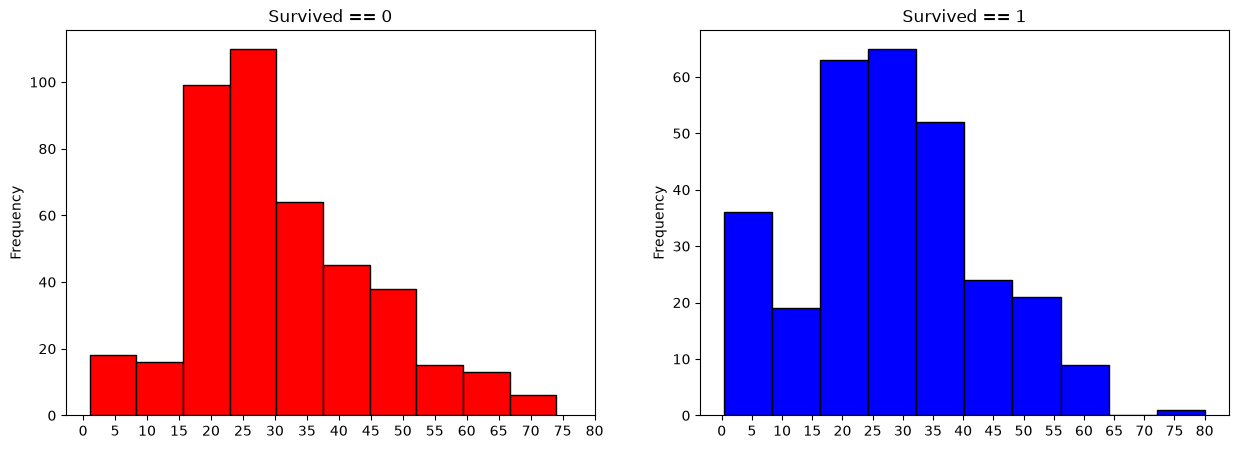

In [79]:
f,ax = plt.subplots(1,2,figsize=(15,5))
train_data[train_data['Survived'] == 0]['Age'].plot.hist(ax=ax[0],edgecolor='black',color='r')
ax[0].set_title('Survived == 0')
x0 = np.arange(0,85,5)
ax[0].set_xticks(x0)
train_data[train_data['Survived'] == 1]['Age'].plot.hist(ax=ax[1],edgecolor='black',color='b')
x1 = np.arange(0,85,5)
ax[1].set_title('Survived == 1')
ax[1].set_xticks(x0)
plt.show()


In [118]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean)
train_data['Age'].isna().sum()

np.int64(0)

По графику видно, что спасли большую часть детей. Так как в train датасете есть довольно большое кол-во пропусков в столбце age, то их можно заменить средним
 значением по возрасту

### Feature Generation

Перед тем как очищать данные, я принимаю решение сделать несколько новых признаков на основе различных обсуждений в разделе дискусий

1) Создать признак is_Alone, который будет говорить о том единственный ли из своей семьи был человек на борту

In [81]:
train_data['is_Alone'] = ((train_data['SibSp'] == 0) & (train_data['Parch'] == 0)).astype(int)
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_Alone
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


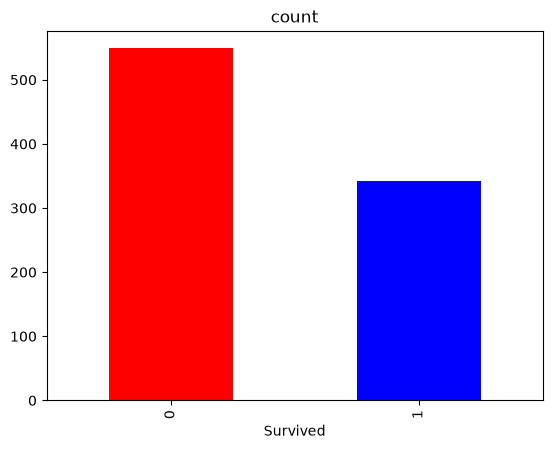

In [92]:
ax = train_data.groupby('Survived')['is_Alone'].count().plot.bar(color=['r','b'])
ax.set_title('count')
plt.show()

2) Создать признак Title, который говорит о титуле человека. А также удалим ненужный столбец с именами

In [97]:
train_data['Title'] = train_data.Name.str.extract('([A-Za-z]+)\.')
train_data = train_data.drop(columns=['Name'])
train_data.head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Артем\AppData\Local\Temp\ipykernel_9704\466559923.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_data['Title'] = train_data.Name.str.extract('([A-Za-z]+)\.')


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_Alone,Title
PassengerId,,,,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,Mr
2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,0,Mrs
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
4,1,1,female,35.0,1,0,113803,53.1000,C123,S,0,Mrs
5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,1,Mr


3) Создадим признак Deck, который нам будет говорить об местоположении кабины человека если она имеется

In [ ]:
train_data['Deck'] = train_data['Cabin'].str[0].fillna('No_info')
train_data = train_data.drop(columns='Cabin')
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,is_Alone,Title,Deck
PassengerId,,,,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,Mr,No_info
2,1,1,female,38.0,1,0,PC 17599,71.2833,C,0,Mrs,C
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Miss,No_info
4,1,1,female,35.0,1,0,113803,53.1000,S,0,Mrs,C
5,0,3,male,35.0,0,0,373450,8.0500,S,1,Mr,No_info


In [108]:
train_data.groupby('Deck')['Survived'].count()

Deck
A           15
B           47
C           59
D           33
E           32
F           13
G            4
No_info    687
T            1
Name: Survived, dtype: int64

In [111]:
train_data = train_data[(train_data['Deck'] != 'T') & (train_data['Deck'] != 'G')]
train_data.groupby('Deck')['Survived'].count()

Deck
A           15
B           47
C           59
D           33
E           32
F           13
No_info    687
Name: Survived, dtype: int64

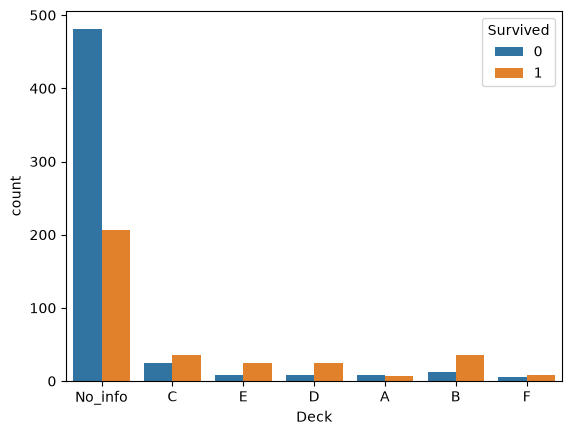

In [116]:
sns.countplot(
    data=train_data,
    x="Deck",
    hue="Survived"
)

plt.show()

In [ ]:
train_data = train_data.dropna()
train_data.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
is_Alone    0
Title       0
Deck        0
dtype: int64

In [125]:
train_data = train_data.drop(columns='Ticket')
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,is_Alone,Title,Deck
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,0,Mr,No_info
2,1,1,female,38.0,1,0,71.2833,C,0,Mrs,C
3,1,3,female,26.0,0,0,7.9250,S,1,Miss,No_info
4,1,1,female,35.0,1,0,53.1000,S,0,Mrs,C
5,0,3,male,35.0,0,0,8.0500,S,1,Mr,No_info


Теперь признаки готовы. Осталось сделать файл в котором при дальнейшем обучении можно было бы менять датасет, где-то добавлять признаки, а где-то оставлять. Реализую file fc.py

### Ready Dataset

Создадим несколько вспомогательных функций для того, чтобы можно было гибко управлять датасетом

In [2]:
import func

In [3]:
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

In [52]:
test_data = func.preprocessing(train_data=test_data)
woman_title = ['Dona','Dr','Ms']
man_title = ['Rev','Col']
test_data['Title'] = test_data['Title'].replace(woman_title, 'Miss')
test_data['Title'] = test_data['Title'].replace(man_title, 'Mr')
test_data = func.encoder(test_data,['Embarked','Title','Deck'],method=1) 
PassengerId = test_data['PassengerId']
test_data = test_data.drop(columns=['PassengerId'])
test_data = func.encoder(test_data,['Sex'],2) 
test_data.columns


Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'is_Alone',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_No_info'],
      dtype='str')

In [53]:
train_data1 = func.preprocessing(train_data=train_data) #преобразую данные как в разделе EDA и Feature Generation
train_data1 = train_data1.drop(columns='PassengerId')
woman_title = ['Lady','Ms','Mme','Mlle']
man_title = ['Jonkheer','Countess','Capt','Sir','Don','Col','Major','Rev','Dr']
train_data1['Title'] = train_data1['Title'].replace(woman_title,'Miss')
train_data1['Title'] = train_data1['Title'].replace(man_title,'Mr')
train_data1 = func.encoder(train_data1,['Embarked','Title','Deck'],method=1) #Произвожу OneHotEncoding по данным колонкам
train_data1 = func.encoder(train_data1,['Sex'],2) #произвожу LabelEncoding по колонке Sex, тем самым заменяю её на 0 и 1

train_data1.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'is_Alone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Deck_A', 'Deck_B', 'Deck_C',
       'Deck_D', 'Deck_E', 'Deck_F', 'Deck_No_info'],
      dtype='str')

In [54]:
X,y = func.sech(train_data1,'Survived') #делю датасет на таргет и признаки
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train,X_test,scale = func.normalise_train_test(X_train,X_test) #Делаю стандартизацию (без утечки данных)
scale.transform(test_data)
print(test_data.shape)
X_train.shape



(418, 21)


(712, 21)

Таким образом мы подготовили train И test датасеты для дальнейшего садмита, приведя их к одинаковому размеру

### KNN

реализую функциюю knn и посмотрю зависимость метрик от кол-ва соседей и самого датасета

In [7]:
model = func.knn(X_train,X_test,y_train,y_test,nei=1,metrics=[accuracy_score])
print('\n\n')
model = func.knn(X_train,X_test,y_train,y_test,nei=3,metrics=[accuracy_score])
print('\n\n')
model = func.knn(X_train,X_test,y_train,y_test,nei=5,metrics=[accuracy_score])
print('\n\n')
model = func.knn(X_train,X_test,y_train,y_test,nei=28,metrics=[accuracy_score])

accuracy_score_train:  0.9789
accuracy_score_test:  0.6760



accuracy_score_train:  0.8834
accuracy_score_test:  0.7989



accuracy_score_train:  0.8652
accuracy_score_test:  0.7989



accuracy_score_train:  0.8062
accuracy_score_test:  0.7933


По этому эксперименту можно сделать вывод о том, что диапазон соседей, в котором результат равен 0.7989 будет самым лучшим для полной реализации данной модели под наш датасет. Видно, что при 1 соседе модель ловит переобучение и при этом качество тестовой выборки падает ниже, чем наш лучший результат. Также слишком большое кол-во соседей негативно влияет на нашу оценку. Для того, чтобы узнать как влияют новые фичи в датасете на данную модель, сменим настройки создания датасета и создадим новую модель

In [8]:
def full_prepocessing(train_data1,alone=True,title=True,deck=True,method=1,encod_columns=[],test_size=0.2,norm=True):
    train_data1 = func.preprocessing(train_data=train_data,alone=alone,title=title,deck=deck)
    train_data1 = func.encoder(train_data1,encod_columns,method=method) 
    train_data1 = func.encoder(train_data1,['Sex'],2) 
    X,y = func.sech(train_data1,'Survived') 
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=test_size,random_state=42,stratify=y)
    if norm:
        X_train,X_test,scaler = func.normalise_train_test(X_train,X_test)
    return X_train,X_test,y_train,y_test

print('--Без Feature Enginering--',end='\n')
X_train,X_test,y_train,y_test = full_prepocessing(train_data1=train_data,alone=False,title=False,deck=False,encod_columns=['Embarked'])
model = func.knn(X_train,X_test,y_train,y_test,metrics=[accuracy_score])
print('\n')
print('--С LabelEncoding--',end='\n')
X_train,X_test,y_train,y_test = full_prepocessing(train_data1=train_data,method=2,encod_columns=['Embarked','Deck','Title'])
model = func.knn(X_train,X_test,y_train,y_test,metrics=[accuracy_score])
print('\n')
print('--С OneHotEncoding--',end='\n')
X_train,X_test,y_train,y_test = full_prepocessing(train_data1=train_data,method=1,encod_columns=['Embarked','Deck','Title'])
model = func.knn(X_train,X_test,y_train,y_test,metrics=[accuracy_score])
print('\n')
print('--С увеличенным test_size--',end='\n')
X_train,X_test,y_train,y_test = full_prepocessing(train_data1=train_data,method=1,encod_columns=['Embarked','Deck','Title'],test_size=0.4)
model = func.knn(X_train,X_test,y_train,y_test,metrics=[accuracy_score])
print('\n')
print('--Без нормирования--',end='\n')
X_train,X_test,y_train,y_test = full_prepocessing(train_data1=train_data,method=1,encod_columns=['Embarked','Deck','Title'],test_size=0.2,norm=False)
model = func.knn(X_train,X_test,y_train,y_test,metrics=[accuracy_score])

--Без Feature Enginering--
accuracy_score_train:  0.8736
accuracy_score_test:  0.7486


--С LabelEncoding--
accuracy_score_train:  0.8876
accuracy_score_test:  0.7542


--С OneHotEncoding--
accuracy_score_train:  0.8890
accuracy_score_test:  0.7765


--С увеличенным test_size--
accuracy_score_train:  0.8783
accuracy_score_test:  0.7843


--Без нормирования--
accuracy_score_train:  0.7921
accuracy_score_test:  0.6089


Feature Engineering улучшил качество модели KNN с 0.7486 до 0.7989. Среди способов кодирования категориальных признаков One-Hot Encoding показал лучший результат, чем Label Encoding. Отключение нормализации значительно ухудшило качество модели, что ожидаемо для алгоритма KNN, использующего расстояния между объектами. Изменение test_size до 0.4 привело к более высокому значению Accuracy, однако этот результат нельзя напрямую сравнивать с предыдущими, поскольку изменилась тестовая выборка.

In [3]:
test_data,X_train,X_test,y_train,y_test,PassengerId = func.ready_data()
model = model = func.knn(X_train,X_test,y_train,y_test,nei=5,metrics=[accuracy_score])
func.submit(test_data,model,'knn',PassengerId=PassengerId)

accuracy_score_train:  0.8652
accuracy_score_test:  0.7989


после submit мы получили вот такие результаты. Расхождение довольно небольшие в отличии от результатов на тесте.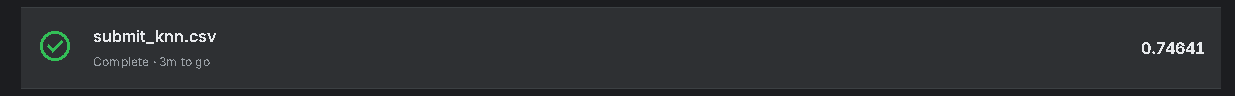

### Logistic Regression

Создадим функцию для работы с логистической регрссией. За основу возьмём уже реализованную функцию для knn

In [22]:
model = func.logReg(X_train,X_test,y_train,y_test,metrics=[accuracy_score])
print('\n\n')
model = func.logReg(X_train,X_test,y_train,y_test,C=0.01,metrics=[accuracy_score])
print('\n\n')
model = func.logReg(X_train,X_test,y_train,y_test,l1_ratio=1,metrics=[accuracy_score])
print('\n\n')
model = func.logReg(X_train,X_test,y_train,y_test,l1_ratio=0.2,metrics=[accuracy_score])
print('\n\n')
model = func.logReg(X_train,X_test,y_train,y_test,max_iter=100,metrics=[accuracy_score])

accuracy_score_train:  0.8357
accuracy_score_test:  0.8380



accuracy_score_train:  0.8287
accuracy_score_test:  0.8212



accuracy_score_train:  0.8385
accuracy_score_test:  0.8436



accuracy_score_train:  0.8357
accuracy_score_test:  0.8380



accuracy_score_train:  0.8357
accuracy_score_test:  0.8380


Изменение силы регуляризации оказало наибольшее влияние на качество модели. Использование L1-регуляризации улучшило результат по сравнению с Elastic net. Изменение количества итераций оптимизации не повлияло на качество, так как модель сходилась уже при значении max_iter=100.

### Decision Tree and Random Forest

Как и у предыдущих моделей создадим функцию и поиграем с гиперпараметрами

In [23]:
model = func.default_tree(X_train,X_test,y_train,y_test,metrics=[accuracy_score,f1_score])
print('')
model = func.default_tree(X_train,X_test,y_train,y_test,max_depth=3,min_samples_leaf=5,min_samples_split=10,metrics=[accuracy_score,f1_score])

accuracy_score_train:  0.8539
accuracy_score_test:  0.8045
f1_score_train:  0.7928
f1_score_test:  0.7154

accuracy_score_train:  0.8301
accuracy_score_test:  0.8380
f1_score_train:  0.7678
f1_score_test:  0.7752


Здесь мы сталкиваемся с проблемой, которая заключается в большой вариативности комбинаций гиперпараметров. Можно написать три вложенных цикла, а можно воспользоваться функцией GridSearchCV где мы сможем подобрать лучшие гиперпараметры и ко всему прочему будем использовать cross validation, которая даст нам более честную оценку для нашего датасета.

In [24]:
param = {
    "max_depth" : np.arange(5,21,5),
    'min_samples_split' : np.arange(5,21,5),
    'min_samples_leaf': np.arange(1,16,5)
}
grid = GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=param,scoring='accuracy',cv=5)
grid.fit(X_train,y_train)
model = grid.best_estimator_
print(grid.best_params_,end='\n')
print(f'Best result: {grid.best_score_}')

{'max_depth': np.int64(5), 'min_samples_leaf': np.int64(11), 'min_samples_split': np.int64(5)}
Best result: 0.8160839160839162


In [4]:
test_data,X_train,X_test,y_train,y_test,PassengerId = func.ready_data()
model = model = func.default_tree(X_train,X_test,y_train,y_test,max_depth=5,min_samples_leaf=11,min_samples_split=5,metrics=[accuracy_score])
func.submit(test_data,model,'defTree',PassengerId=PassengerId)

accuracy_score_train:  0.8539
accuracy_score_test:  0.8045


Сделал sabmit для обычного дерева и получил обыкновенный результат. Он немного отличается от результата на Knn.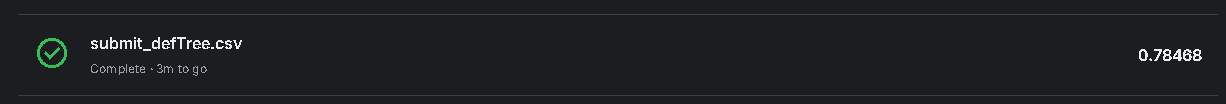

Как мы видим с помощью подбора гиперпараметров мы сильно увеличили значение метрики, а также сделали более честную оценку.

In [9]:
param = {
    'n_estimators': [50,100,200,300,500],
    "max_depth" : [5,10,15],
    'min_samples_split' : [10,15,20],
    'min_samples_leaf': [1,5,10]
}
grid_random = GridSearchCV(param_grid=param,estimator=RandomForestClassifier(),scoring='accuracy',cv=5)
grid_random.fit(X_train,y_train)
model = grid_random.best_estimator_
print(grid_random.best_params_)
print(f'Best score: {grid_random.best_score_}')

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 200}
Best score: 0.8301290259036737


Как оказалось довольно плохая практика делать настолько большой перебор параметров, но так как наш датасет довольно маленький, то для теста не помешало перебрать их так много. Сравним нашу метрику на 5 фолдах с обычным Random Forest и этими же параметрами

In [10]:
model_forest = RandomForestClassifier(n_estimators=200,max_depth=15,min_samples_leaf=1,min_samples_split=15)
model_forest.fit(X_train,y_train)
pred_train = model_forest.predict(X_train)
pred_test = model_forest.predict(X_test)

print(f'Accuracy_score_train:  {accuracy_score(y_train,pred_train)}')
print(f'Accuracy_score_test:  {accuracy_score(y_test,pred_test)}')

Accuracy_score_train:  0.8890449438202247
Accuracy_score_test:  0.8212290502793296


После перебора мы нашли оптимальные гиперпараметры  иувидели следующее. Наши результаты не сошлись с результатами, которые были при их подборе. Почему так? Я полагаю, что это произошло из-за cross validation встроенной в подбор гиперпараметров. Оценка GridSearch оказалось честнее оценки с подобранными гипераметрами. Для того, чтобы убедиться в этом, сделаем кросс валидацию для нашей модели

In [11]:
scores = cross_val_score(model_forest,X_train,y_train,cv=5,scoring='accuracy')
print(f'Result: {scores}')
print(f'Mean Result: {sum(scores)/len(scores)}')

Result: [0.7972028  0.79020979 0.81690141 0.86619718 0.81690141]
Mean Result: 0.8174825174825175


Здесь мы видим результат, который подтверждает мои догадки. А значит score нашего Random Forest будет 0.83-0.84

In [12]:
test_data,X_train,X_test,y_train,y_test,PassengerId = func.ready_data()
func.submit(test_data,model_forest,'RandomTree',PassengerId=PassengerId)

Здесь результат немного уменьшился по сравнению с одним деревом. 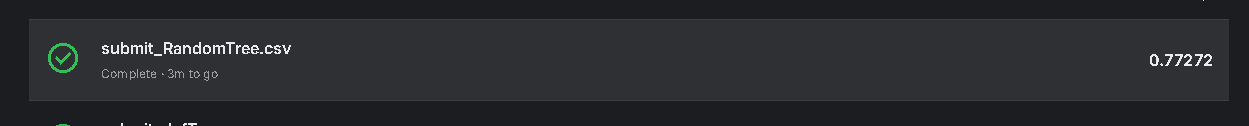

### XGBoost / LightGBM / CatBoost

In [ ]:
from xgboost import XGBClassifier